<a href="https://colab.research.google.com/github/HuBiZuk/AI_Study/blob/main/03_04_%ED%8A%B9%EC%84%B1%EA%B3%B5%ED%95%99_%EA%B7%9C%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 특성공학
# 여러 특성을 사용한 다중회귀에 대해서 알아보자.
# 다항회귀로는 농어의 무게를 어느정도인지 짐작할수는 있다.(과소적합?)
# 과소적합을 해결하려면 제곱보다 더 고차항을 넣어야함
# -> 길이 + 무게 +높이 + 두께 등...

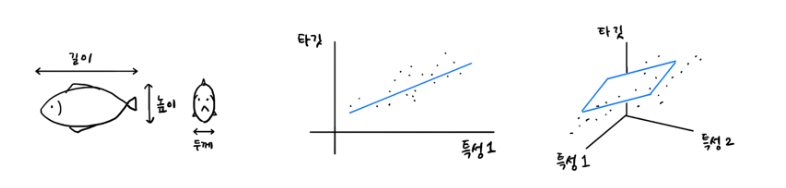

In [11]:
# 다중회귀: 여러개의 특성을 사용한 선형회귀

# 농어의 길이 뿐만 아니라 농어의 높이도 두께도 특성에 포함(특성 3개)
# 3개의 특성을 제곱하여 추가해야 한다.
# 각 특성을 서로 곱해서 도 다른 특성을 만들수 있다.
# 이런 특성을 사용해서 새로운 특성을 뽑아내는 것을 특성공학 이라고 함

# 데이터 준비 -> 판다스에서 제공하는 데이터 프레임을 사용해보다
# 판다스: 데이터 분석용 라이브러리(CSV -> 배열로)
# CSV 파일은 엑셀에서 텍스트를 뽑아낸 텍스트 파일

import pandas as pd # 관례적인 판다스 별칭
# 다중회귀: 물고기의 길이와 무게도 있지만 너비도 존재하니
# 더 자세한 회귀가 도출 될거임 (3차원 공간을 형성함)

df=pd.read_csv('https://bit.ly/perch_csv_data')
perch_full = df.to_numpy() # csv 파일을 가져와 넘파이 배열로 변경
print(perch_full) # perch_full 3개의 특성을 가진 배열 값

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [9]:
# length, height, width
# 길이    높이    너비
import numpy as np

# 무게 타깃 (정답파일용)
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )


In [12]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42)
# 훈련 세트와 테스트 세트로 나눔
print(train_input[0], train_target[0])
# 판다스에서 받은 데이터 length, height, width ewight[19.6   5.14  3.04] 85.0

[19.6   5.14  3.04] 85.0


In [13]:
print(train_input.shape, test_input.shape)
# 훈련용 42개 농어와 3개 특성
# 훈련용 14개 농어와 3개 특성

(42, 3) (14, 3)


In [16]:
# 위 데이터를 사용해서 새로운 특성을 만들겠다!
# 사이킷런 변환기 :  특성을 만들거나 전처리하는 클래스가 있다.
# 변환기(Transformer) : fit(), transform()메서드가 있다.

from sklearn.preprocessing import PolynomialFeatures # 특성변환기

poly = PolynomialFeatures()
poly.fit([[2,3]])
# 2개의 특성을 가진 2와 3으로 이루어진 샘플 하나를 적용 테스트
print(poly.transform([[2,3]]))
# fit()메서드와 transform()메서드를 차례대로 실행( 훈련을 해야 변환이 됨)

[[1. 2. 3. 4. 6. 9.]]


In [17]:
# [[1.2.3.4.6.9.]]
# 1(baias)
# 2     #fit에 첫번째값
# 3     # fit에 두번째 값
# 4 = 2**2
# 5 = 2*3
# 9 = 3**2

# PolynomialFeature는 기본적으로 각 특성을 제곱한 항을 추가하고
# 특성끼리 서로 곱한 항을 추가함
# 2와 3을 각기 제곱한 4와 9가 추가 되고, 2와 3을 곱한 6이 추가됨
# 무게 = a*길이+b*높이+c*두꼐+ㅇ+1
# 선형 방정식의 절편을 항상 값이 1인 특성과 곱해지는 계수임 -> (길이, 높이ㅡ 두께, 1)

In [18]:
poly = PolynomialFeatures(include_bias=False)
                            # 1 삭제 (자동으로 절편 항은 무시하지만 알아두면 좋음)
poly.fit([[2,3]])
print(poly.transform([[2,3]]))    # 특성에 1이 무조건 계산되지 않기 때문에 속도 향상됨

[[2. 3. 4. 6. 9.]]


In [20]:
poly.get_feature_names_out()  # 특성이 어떻게 만들어졌는지 확인

array(['x0', 'x1', 'x0^2', 'x0 x1', 'x1^2'], dtype=object)

In [22]:
# 실제로 훈련 시작용 생성
poly = PolynomialFeatures(include_bias=False)
# 사이킷런의 선형 모델은 자동으로 bias를 추가하므로
# bias 특성을 만들필요가 없음 include_bias를 False로 지정한다
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape) # 42개의 요소에 9개의 특성(3개의 특성을 공학으로 9개로 늘림)
# 무게, 높이, 두께를 다중 결합하여 특성을 만듬 (특성공학)

(42, 9)


In [23]:
poly.get_feature_names_out() # 특성이 어떻게 만들어졌는지 확인

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [25]:

#[ 'x0',   'x1',  'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2', 'x2^2']
# length, height, width length^2
#                            length*height
#                                     length*width
#                                                height^2
#                                                      height*width
#                                                                  width^2

In [26]:
test_poly = poly.transform(test_input) # 테스트용 세트 변환

In [30]:
# 다중 회귀모델 훈련하기
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
# 99.03%의 아주 조은 점수가 나옴( 물고기의 길이, 높이, 두께까지 사용한 결과)


0.9903183436982125


In [31]:
print(lr.score(test_poly, test_target))
# 97.14% 농어의 길이만을 사용 했을때에 있던 과소적함문제는 나타나지 않음

0.9714559911594111


In [33]:
print(poly.degree)  # 특성조합수 기본값 2

2


In [34]:
# 만약 정확한 값을 보기 위해서 특성 조합수를 더 늘리면?
# 특성을 추가하여 3제곱 4, 5 제곱 항을 추가
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)
# 특성개수 55로 증가

(42, 55)


In [35]:
poly.get_feature_names_out() # 특성이 어쩧게 만들어졌는지 확인


array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2', 'x0^3', 'x0^2 x1', 'x0^2 x2', 'x0 x1^2', 'x0 x1 x2',
       'x0 x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3', 'x0^4', 'x0^3 x1',
       'x0^3 x2', 'x0^2 x1^2', 'x0^2 x1 x2', 'x0^2 x2^2', 'x0 x1^3',
       'x0 x1^2 x2', 'x0 x1 x2^2', 'x0 x2^3', 'x1^4', 'x1^3 x2',
       'x1^2 x2^2', 'x1 x2^3', 'x2^4', 'x0^5', 'x0^4 x1', 'x0^4 x2',
       'x0^3 x1^2', 'x0^3 x1 x2', 'x0^3 x2^2', 'x0^2 x1^3',
       'x0^2 x1^2 x2', 'x0^2 x1 x2^2', 'x0^2 x2^3', 'x0 x1^4',
       'x0 x1^3 x2', 'x0 x1^2 x2^2', 'x0 x1 x2^3', 'x0 x2^4', 'x1^5',
       'x1^4 x2', 'x1^3 x2^2', 'x1^2 x2^3', 'x1 x2^4', 'x2^5'],
      dtype=object)

In [37]:
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9999999999996433


In [39]:
print(lr.score(test_poly, test_target)) # 테스트 점수가 왜이럼??
# 훈련용 데이터는 42, 3
#테스트용 데이터는 14, 3
# 자료보다 특성이 많아서 생긴 결과뭉

# 특성개수를 크게 늘리면 선형모델은 아주 강력해짐
# 하지만 이런 모델은 훈련 세트에 너무 과대적합됨
# 특히 훈련세가 44개 이지만 55개의 특성을 넣으면 어떻게 될까요??

-144.40579436844948


In [ ]:
# 규제(regularization) : 훈련세트를 너무 과도하게 학습하지 못하게 훼방하는것
# 훈련세트에 과대적합이 되지 않도록 만드는것 (95% 이내의 확률을 만들자!)

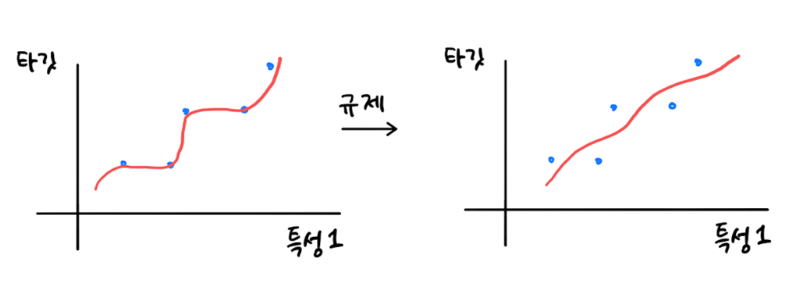

In [41]:
from sklearn.preprocessing import StandardScaler
# StandardScaler 싸이킷런 데이터 전처리 스케일 조정(스케일러) -> 표준화 점수로 변환시켜줌
ss= StandardScaler()  # 훈련세트로 학습한 변환기를 사용해 테스트 세트까지 변환 필수
ss.fit(train_poly)

train_scaled = ss.transform(train_poly) # 트레이닝용
test_scaled = ss.transform(test_poly)   # 테스트용
# 표준 점수로 변환한 train_scaled 준비 완료
# 평균과 표준편차로 공식을 적용할 필요가 없다(표준점수화 됨)

In [42]:
# 선형 회귀 모델에 규제를 추가한 모델은 2개가 있다.
# 릿지(ridge) : 계수를 제곱한 기준으로 규제(선호)
# 라쏘(lasso) : 계수의 절대값을 기준으로 규제를 적용 -> 0으로 제공 가능

In [44]:
# 릿지회귀 : 모델 객체를 만들고 fit() -> score()
from sklearn.linear_model import Ridge

ridge = Ridge() # 릿지 클래스를 객체로 생성하고 변수 연결
ridge.fit(train_scaled, train_target) # fit로 훈련하고 score로 평가함
print(ridge.score(train_scaled, train_target))
# 테스트 결과를 좋은 성능임을 판단할수 있다.
# 모델객체 생성시 alpha 매개변수로 규제의 강도를 조절함

0.9896101671037343


In [46]:
print(ridge.score(test_scaled, test_target))

0.9790693977615387


In [56]:
# 릿지와 라쏘 모델을 사용할 때 규제의 양을 임으로 조절할 수 있다.
# 모델 객체를 만들때 alpha 매개값을 주면 됨
# alpha 값을 크게 주면 강도가 세짐, 계수값을 더 줄이고 조금 더 과소적합되록 유도하는 용도

# 적절한 alpha 값을 찾는 방법은 그래프로 그려 봐야 한다.
import matplotlib.pyplot as plt

train_score = []    # 훈련 :규제의 알파 농도따라서 결과 %를 기록저장용
test_score = []     # 테스트 % 저장용
# alpha 값을 바꿀때 마다 score() 메서드의 결과 값을 저장할 리스트 생성

In [57]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100] # 0.001 ~ 100까지 10배씩 증가
for alpha in alpha_list:    # 리스트 반복용
    # 릿지 모델을 만듭니다
    ridge = Ridge(alpha=alpha)
    # 릿지 모델을 훈련합니다
    ridge.fit(train_scaled, train_target)
    # 훈련 점수와 테스트 점수를 저장합니다
    train_score.append(ridge.score(train_scaled, train_target)) # 훈련점수를 리스트에 보관
    test_score.append(ridge.score(test_scaled, test_target))    # 테스트점수를 리스트에 보관
print(f"train_score {train_score}")
print(f"test_score {test_score}")

train_score [0.9930455252088248, 0.991780998125052, 0.9903815817570367, 0.9896101671037343, 0.988728468997471, 0.9841843235774494]
test_score [0.9569388961567329, 0.9800187936871725, 0.9827976465386928, 0.9790693977615387, 0.9725329582461569, 0.9627042641050291]


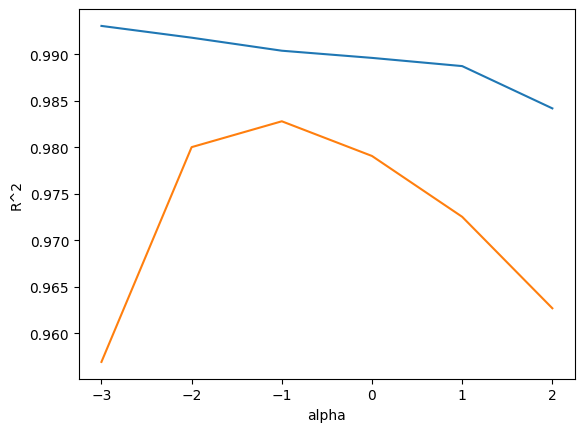

In [58]:
# 위 결과를 차트로 보자!!!

# .log10(alpha_list) x축 값이 너무 촘촘하게 보일까봐 지수형식으로 표현
# 0.001 : -3, 0.01 : -2  0.1 : -1
plt.plot(np.log10(alpha_list), train_score) # 파란색
plt.plot(np.log10(alpha_list), test_score) # 주황색
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show() # 0.1 일때 제일 좋은 점수로 파악이 됨

In [60]:
ridge = Ridge(alpha=0.1)    # 제일 좋은 값으로 적용
ridge.fit(train_scaled, train_target)   # 훈련

print(ridge.score(train_scaled, train_target))  # 평가 99.03%
print(ridge.score(test_scaled, test_target))    # 테스트 98.27%

0.9903815817570367
0.9827976465386928


In [62]:
# 라쏘로 규제 해보기

from sklearn.linear_model import Lasso # import 부분이 변경됨

lasso = Lasso() # 이부분이 변경됨
lasso.fit(train_scaled, train_target) # 훈련하고 점수환산
print(lasso.score(train_scaled, train_target))

0.989789897208096


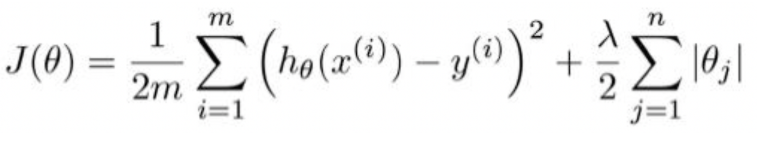

In [63]:
print(lasso.score(test_scaled, test_target)) # 릿지 만큼의 규제가 적용되어 안정적이다.

0.9800593698421883


In [64]:
# 지금도 안정적이지만 알파값을 조절하면 더 좋은 값을 찾을수 있겠다??
train_score =[]
test_score =[]

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
  # 라쏘모델 만들기
  lasso = Lasso(alpha=alpha, max_iter=100000)   # 최대 반복 횟수(정확도를 위함)
  # 라쏘 모델은 최적의 계수를 찾기 위해 반복적인 계산을 수행함

  # 라쏘 모델을 훈련
  lasso.fit(train_scaled, train_target)
  # 훈련 점수와 테스트 점수를 위해 만든 리스트에 저장
  train_score.append(lasso.score(train_scaled, train_target))
  test_score.append(lasso.score(test_scaled, test_target))
# 라쏘 테스트시 반복계산을 하는데 지정한 반복횟수가 부족하면 경고가 발생 convergenceWarning


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.393e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.440e+03, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


Text(0, 0.5, 'R^2')

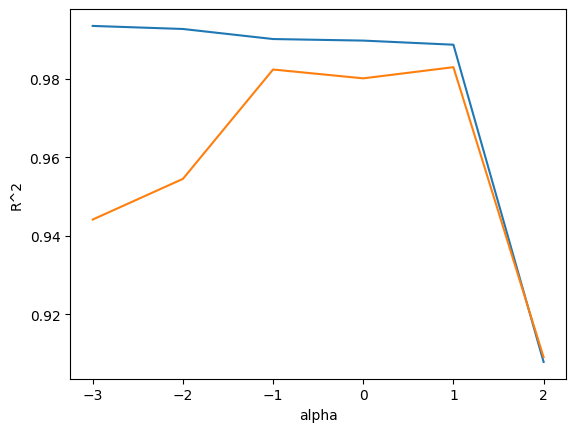

In [65]:
# 위에서 만든 리스트를 차트로 보자
plt. plot(np.log10(alpha_list), train_score) # 파란색
plt. plot(np.log10(alpha_list), test_score)   # 주황색
plt.xlabel('alpha')
plt.ylabel('R^2')

# 왼쪽은 과대 적합, 오른쪽은 정상 (제일 좋은 값은 1 => 10)

In [67]:
# 라소 모델의 최적의 알파값은 1-> 10^1 =10
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target)) # 98.88%
print(lasso.score(test_scaled, test_target))   #98.24%

0.9888067471131867
0.9824470598706695


## **노트북의 목표: 농어의 무게를 정확하게 예측하기**

이 노트북은 농어의 여러 가지 특성(길이, 높이, 두께)을 사용하여 농어의 무게를 예측하는 머신러닝 모델을 만드는 과정을 보여줍니다. 특히, **'특성 공학(Feature Engineering)'**과 **'규제(Regularization)'**라는 중요한 개념을 통해 모델의 성능을 향상시키고 과대적합(Overfitting)을 방지하는 방법을 알아봅니다.

---

### **1단계: 데이터 준비 및 탐색**

*   **데이터 불러오기**: `pandas` 라이브러리를 사용하여 농어의 길이, 높이, 두께 데이터(`perch_full`)와 실제 무게 데이터(`perch_weight`)를 불러왔습니다.
*   **훈련/테스트 세트 분할**: 모델을 훈련하고 평가하기 위해 데이터를 `train_test_split` 함수로 훈련 세트와 테스트 세트로 나눴습니다. (약 75%는 훈련에, 25%는 평가에 사용됩니다.)

---

### **2단계: 특성 공학 (Feature Engineering)**

이전에는 농어의 길이 하나만으로 무게를 예측했지만, 이번에는 더 많은 정보를 활용합니다.

*   **왜 필요한가요?**: 농어의 무게는 길이뿐만 아니라 높이나 두께에도 영향을 받을 것입니다. 또한, 길이의 제곱이나 길이와 높이를 곱한 값처럼 기존 특성들을 조합한 새로운 특성이 무게 예측에 더 큰 도움이 될 수 있습니다. 이렇게 기존 특성을 바탕으로 새로운 특성을 만드는 것을 '특성 공학'이라고 합니다.

*   **`PolynomialFeatures` 사용**: `sklearn.preprocessing`의 `PolynomialFeatures`를 사용하여 특성을 확장했습니다.
    *   예를 들어, [2, 3]이라는 두 특성 데이터가 있다면, `PolynomialFeatures`는 이를 [1, 2, 3, 4, 6, 9]로 변환합니다. 여기서 '1'은 절편을 위한 특성이고, '4'는 2의 제곱, '9'는 3의 제곱, '6'은 2와 3을 곱한 값입니다.
    *   `include_bias=False` 옵션으로 '1' 특성을 제거했습니다. (선형 모델이 절편을 자동으로 추가하기 때문에 중복을 피하기 위함입니다.)
    *   이 과정을 통해 3개의 특성(길이, 높이, 두께)이 9개의 특성(길이, 높이, 두께, 길이^2, 길이 x 높이, 길이 x 두께, 높이^2, 높이 x 두께, 두께^2)으로 늘어났습니다.

*   **문제점 발견 (과대적합)**:
    *   `degree=5` (5차항까지)로 특성 개수를 55개로 늘렸더니, 훈련 세트 점수는 **0.99999...**로 거의 완벽에 가깝게 나왔습니다. 하지만 테스트 세트 점수는 **-144.40**라는 매우 낮은 음수 값이 나왔습니다. 이는 모델이 훈련 데이터에 **과대적합(Overfitting)**되었다는 강력한 증거입니다. 즉, 훈련 데이터의 아주 사소한 패턴까지 암기하여 실제(새로운) 데이터에서는 전혀 예측을 못하는 상태가 된 것입니다.

---

### **3단계: 특성 스케일링 (표준화)**

*   **왜 필요한가요?**: 특성 공학을 통해 만든 특성들은 값의 범위가 매우 다릅니다. 예를 들어, 길이는 20인데 길이^2는 400일 수 있습니다. 규제 모델은 이런 특성들의 스케일에 민감하기 때문에, 모든 특성을 비슷한 스케일로 맞춰주는 **표준화(Standardization)** 과정이 필요합니다.
*   **`StandardScaler` 사용**: `sklearn.preprocessing`의 `StandardScaler`를 사용하여 모든 특성들의 평균을 0, 표준 편차를 1로 조정했습니다.

---

### **4단계: 규제(Regularization)를 통한 과대적합 방지**

과대적합을 막기 위해 모델에 '벌칙'을 주는 규제 방법을 사용합니다. 계수(기울기)가 너무 커지는 것을 막아 모델을 더 일반화시킵니다.

*   **릿지 (Ridge) 회귀**: 계수 값의 **제곱**에 비례하는 벌칙을 적용합니다.
    *   **특징**: 모든 특성의 계수를 0에 가깝게 줄이지만, 완전히 0으로 만들지는 않습니다. 즉, 모든 특성을 모델에 유지하려는 경향이 있습니다.
    *   **`alpha` 매개변수**: 규제의 강도를 조절합니다. `alpha` 값이 클수록 규제가 강해져 계수들이 더 많이 줄어듭니다.
    *   **결과**: 최적의 `alpha=0.1`일 때 훈련 세트 0.9904, 테스트 세트 0.9828의 점수를 얻었습니다. 이전 `degree=5`의 과대적합 문제를 훌륭하게 해결했습니다.

*   **라쏘 (Lasso) 회귀**: 계수 값의 **절대값**에 비례하는 벌칙을 적용합니다.
    *   **특징**: 일부 특성의 계수를 아예 0으로 만들어버릴 수 있습니다. 이는 사실상 중요하지 않은 특성을 모델에서 제외하는 효과(특성 선택)를 가져옵니다.
    *   **`alpha` 매개변수**: 릿지와 마찬가지로 규제의 강도를 조절합니다.
    *   **결과**: 최적의 `alpha=10`일 때 훈련 세트 0.9888, 테스트 세트 0.9824의 점수를 얻었습니다. 라쏘 역시 과대적합 문제를 해결하고 좋은 성능을 보였습니다.

---

### **5단계: 릿지 vs. 라쏘 모델 성능 비교**

*   **릿지 (최적 `alpha=0.1`)**: 훈련 점수 0.9904, 테스트 점수 0.9828
*   **라쏘 (최적 `alpha=10`)**: 훈련 점수 0.9888, 테스트 점수 0.9824

이 특정 데이터셋에서는 **릿지 모델이 라쏘 모델보다 아주 미미하게 더 나은 성능을 보였습니다.** 두 모델 모두 과대적합을 효과적으로 줄이고 높은 예측 정확도를 달성했지만, 릿지 모델은 모든 특성을 활용하면서 계수를 조절하여 더 좋은 결과를 냈다고 볼 수 있습니다.

---

**요약하자면,**

1.  **특성 공학**으로 농어의 특성을 확장하여 모델에 더 많은 정보를 주었습니다.
2.  하지만 특성이 너무 많아지면 **과대적합** 문제가 발생할 수 있음을 확인했습니다.
3.  **특성 스케일링(표준화)**으로 특성들의 스케일을 맞춰주었습니다.
4.  **릿지(Ridge)**와 **라쏘(Lasso)** 같은 **규제** 방법을 사용하여 과대적합을 방지하고 모델의 일반화 성능을 높였습니다.
5.  최종적으로 릿지 모델이 이 데이터에서는 라쏘 모델보다 약간 더 좋은 예측 성능을 보였습니다.